# Introduction

This analysis examines the **Global Price of Brent Crude Oil** (USD per Barrel), recorded monthly from **January 2016 to January 2025**. Brent Crude is the international benchmark for oil pricing, determined by major exporters and widely used as a reference for global energy markets.

The objectives of this analysis are:
- Understand the long-term behavior and trends in oil prices
- Assess the impact of major economic shocks such as the **COVID-19 pandemic (2020)** and the **Russia-Ukraine war (2022)** on price volatility
- Build a statistical time series model (**ARIMA**) to forecast future oil prices
- Evaluate forecast accuracy and discuss model limitations in the presence of structural breaks

In [2]:
%load_ext rpy2.ipython

In [3]:
%%R
install.packages("forecast")
library(forecast)
install.packages("tseries")
library(tseries)
install.packages("TSA")
library(TSA)
install.packages("ggplot2")
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’

trying URL 'https://cran.rstudio.com/src/contrib/colorspace_2.1-2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/fracdiff_1.5-3.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/lmtest_0.9-40.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/timeDate_4052.112.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/urca_1.3-4.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/zoo_1.8-15.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/RcppArmadillo_15.2.4-1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/forecast_9.0.2.tar.gz'

The downloaded source packages are in
	‘/tmp/Rtmp9ykDsW/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘quant

# Identification
# data preparation

In [4]:
%%R
#x->date of observation
#y->price U.S. Dollars per Barrel
values <- read.csv("POILBREUSDM.csv")
X <- values$observation_date
X <- as.Date(X)
y <- values$POILBREUSDM

split data to train and test set, test set contains 10 observation will be used to calculate forecasting accuracy

In [5]:
%%R
h<-10
n <- length(y)
x_train <- X[1:(n-h)]
y_train <- y[1:(n-h)]
x_test  <- X[(n-h+1):n]
y_test  <- y[(n-h+1):n]

### Visual Inspection

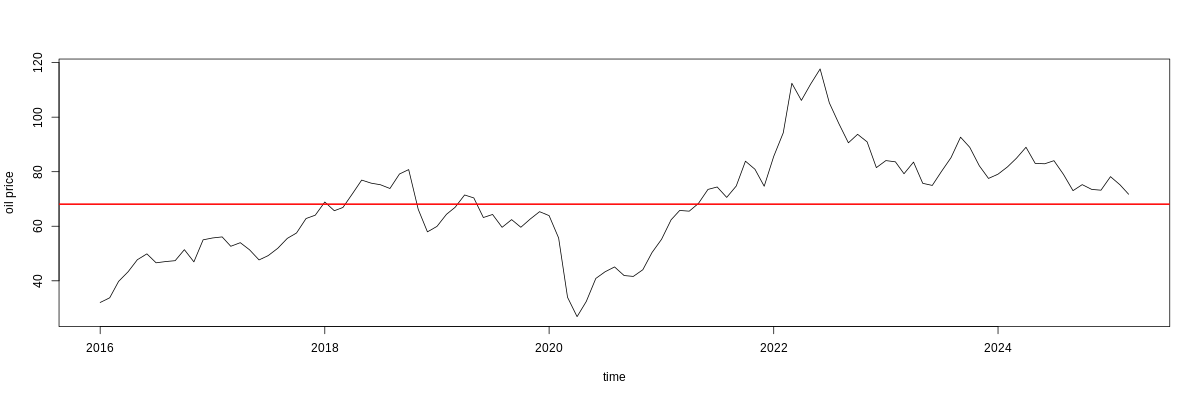

In [6]:
%%R -w 1200 -h 400
plot(x_train, y_train, xlab = "time", ylab = "oil price", type="l")
abline(h = mean(y_train), col = "red", lwd = 2)


The time series plot reveals a **stochastic trend** with several distinct phases driven by major global events:

- **2016 – 2019:** A slow and gradual increase in oil prices, reflecting stable global demand and normal market conditions.
- **2019 – 2021 (COVID-19 Shock):** Prices dropped sharply as the pandemic brought industrial activity to a near halt worldwide, drastically reducing oil demand and leading to a historic price collapse in early 2020.
- **2021 – Mid 2022 (Recovery & War):** Prices surged significantly as post-pandemic industrial recovery boosted demand. This was further amplified by the **Russia-Ukraine war (2022)**, which prompted many countries to halt imports of Russian oil — one of the world's largest suppliers — causing supply fears and pushing prices to their **highest level in over 10 years**.
- **Mid 2022 – 2025:** Prices gradually declined but remained elevated compared to pre-pandemic levels, reflecting persistent geopolitical uncertainty.

From this visual inspection, three key observations can be made:
1. **Trend:** The series exhibits a clear non-constant mean, suggesting **non-stationarity**
2. **Variance:** The variance appears relatively **constant** over time (no volatility clustering visible at this scale)
3. **Seasonality:** No seasonal pattern is apparent in the monthly data

### Stationarity Test


	Augmented Dickey-Fuller Test

data:  y_train
Dickey-Fuller = -2.0328, Lag order = 4, p-value = 0.563
alternative hypothesis: stationary



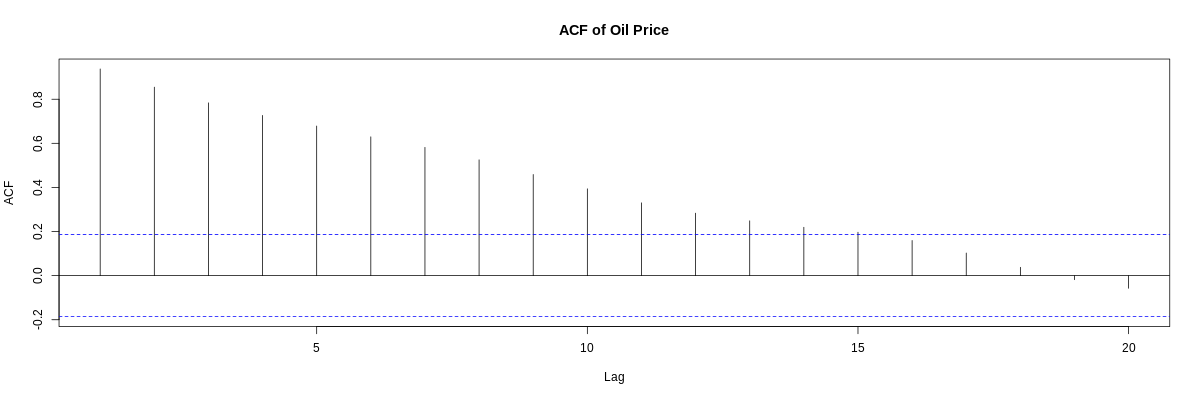

In [7]:
%%R -w 1200 -h 400
acf(y_train, main = "ACF of Oil Price")
adf.test(y_train)


The ACF plot shows a **slow decay**, which is a strong visual indicator of non-stationarity. This is formally confirmed by the **Augmented Dickey-Fuller (ADF) test** (p-value = 0.563 > 0.05), meaning we **fail to reject the null hypothesis** of a unit root. We conclude that the series is **not stationary in its original form** and requires differencing.

### Box-Cox Transformation

In [8]:
%%R
# Automatically finds optimal lambda
lambda_opt <- BoxCox.lambda(y_train)
print(lambda_opt)


[1] 0.8993852


The estimated Box-Cox parameter is **λ ≈ 0.9**, which is very close to 1. Since λ = 1 corresponds to no transformation, this suggests that a **variance-stabilizing transformation is not necessary**, and we can proceed directly with the original series.

### Differencing

In [9]:
%%R
y_diff <- diff(y_train)

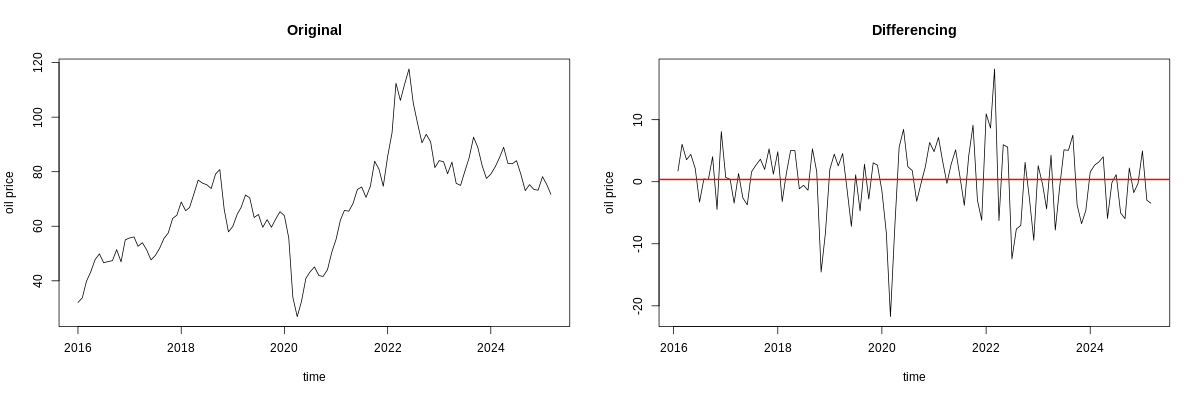

In [27]:
%%R -w 1200 -h 400
par(mfrow = c(1, 2))
plot(x_train, y_train, type = "l", xlab = "time", ylab = "oil price", main = "Original")
plot(x_train[-1], y_diff, type = "l", xlab = "time", ylab = "oil price", main = "Differencing")
abline(h = mean(y_diff), col = "red", lwd = 2)


	Augmented Dickey-Fuller Test

data:  y_diff
Dickey-Fuller = -4.6646, Lag order = 4, p-value = 0.01
alternative hypothesis: stationary



In addition: Warning message:
In adf.test(y_diff) : p-value smaller than printed p-value


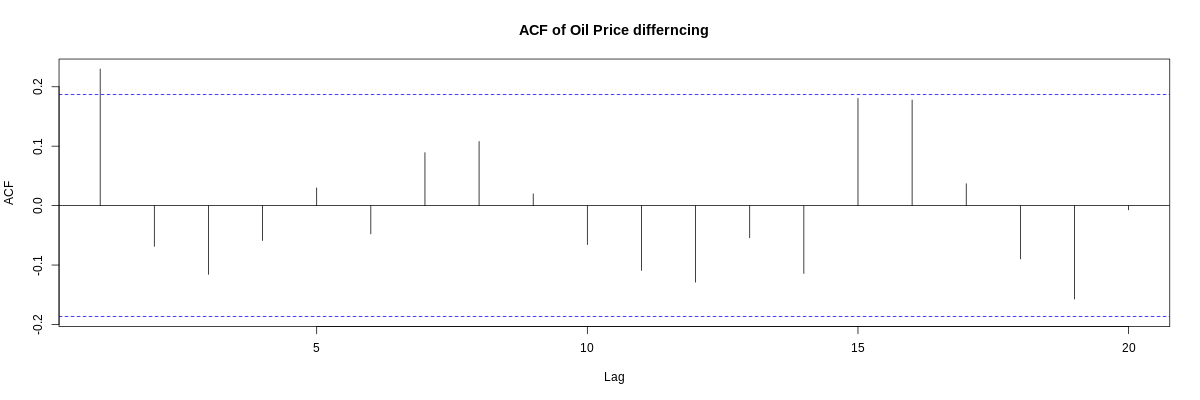

In [11]:
%%R -w 1200 -h 400
acf(y_diff, main = "ACF of Oil Price differncing")
adf.test(y_diff)

After applying first-order differencing, the series appears **stationary**, fluctuating around a **zero mean with roughly constant variance**. This is confirmed by:
- **ACF:** Decays quickly to zero, indicating no remaining autocorrelation structure
- **ADF test:** p-value < 0.05, rejecting the null hypothesis of a unit root

We conclude that the original series is **integrated of order 1 — I(1)**, making $ARIMA(p, 1, q)$ the appropriate model family.

Examining the differenced series also reveals two significant outliers caused by external shocks:
- **COVID-19 pandemic (early 2020):** A sharp **downward spike** reflecting the sudden collapse in global oil demand as industrial activity halted worldwide
- **Russia-Ukraine war (2022):** A sharp **upward spike** driven by supply fears as major economies cut imports of Russian oil, one of the world's largest suppliers



## Model selection

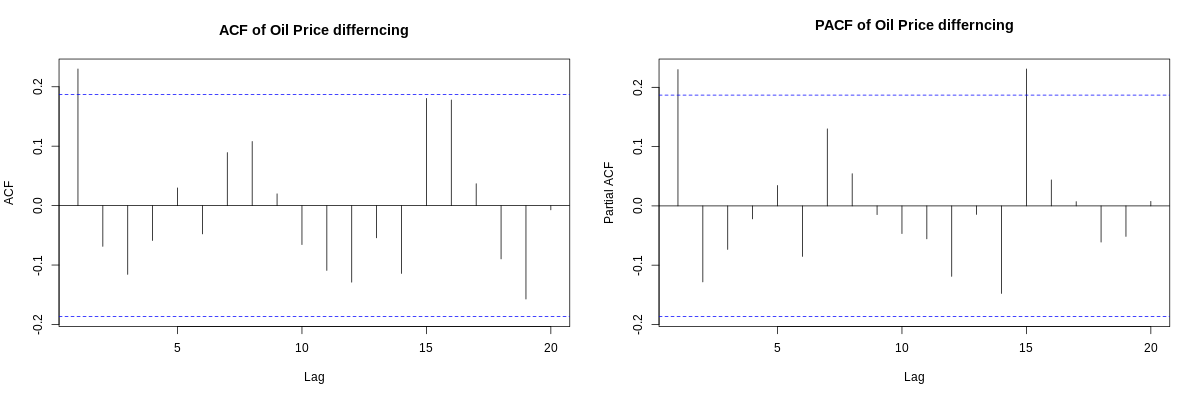

In [12]:
%%R -w 1200 -h 400
par(mfrow = c(1, 2))
acf(y_diff, main = "ACF of Oil Price differncing")
pacf(y_diff, main = "PACF of Oil Price differncing")

Reordering variables and trying again:


In addition: Warning message:
In leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in,  :
  4  linear dependencies found


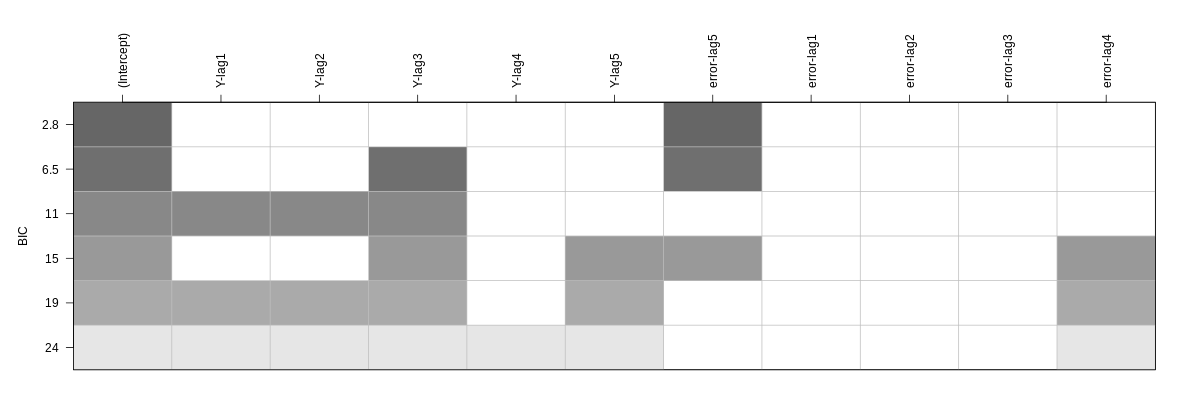

In [13]:
%%R -w 1200 -h 400
plot(armasubsets(y_diff, nar = 5, nma = 5))

In [14]:
%%R
fit <- auto.arima(y_train)
summary(fit)

Series: y_train 
ARIMA(0,1,1) 

Coefficients:
         ma1
      0.2640
s.e.  0.0924

sigma^2 = 28.9:  log likelihood = -340.63
AIC=685.25   AICc=685.37   BIC=690.65

Training set error measures:
                    ME    RMSE      MAE      MPE    MAPE      MASE        ACF1
Training set 0.2784809 5.32715 4.180562 0.295883 6.42827 0.9696441 -0.00613828


Examining the ACF and PACF of the differenced series:

- **ACF:** Shows a significant spike at lag $k=1$, then cuts off sharply — a classic signature of an **MA(1)** process, suggesting $ARIMA(0,1,1)$
- **PACF:** Shows a similar decaying structure, suggesting an **AR(1)** component, supporting $ARIMA(1,1,0)$. A significant spike appears at lag $k=11$, however since it is **isolated and not repeated** at nearby lags, it is considered noise rather than a meaningful seasonal pattern
- **BIC subset plot:** Highlights $ARIMA(0,1,5)$ as a candidate based on information criterion minimization

Based on this analysis, the following candidate models were selected for comparison:

| Model | Justification |
|---|---|
| $ARIMA(0,1,1)$ | ACF cuts off at lag 1 — confirmed by `auto.arima()` |
| $ARIMA(1,1,0)$ | PACF decays after lag 1 |
| $ARIMA(1,1,1)$ | Mixed AR and MA components |
| $ARIMA(0,1,5)$ | Suggested by BIC subset selection plot |

## Estimation & Testing

### Parameter Estimation
The parameters of each candidate model were estimated using **Maximum Likelihood Estimation (MLE)**, which finds the parameter values that maximize the probability of observing the given data under the assumed model structure.

In [15]:
%%R
fit1 = Arima(y_train, order=c(1,1,0),method='ML')
summary(fit1)

Series: y_train 
ARIMA(1,1,0) 

Coefficients:
         ar1
      0.2324
s.e.  0.0924

sigma^2 = 29.17:  log likelihood = -341.14
AIC=686.27   AICc=686.39   BIC=691.67

Training set error measures:
                    ME   RMSE      MAE       MPE     MAPE      MASE      ACF1
Training set 0.2671436 5.3523 4.194892 0.2902667 6.462449 0.9729678 0.0282111


In [16]:
%%R
fit2 = Arima(y_train, order=c(0,1,1))
summary(fit2)

Series: y_train 
ARIMA(0,1,1) 

Coefficients:
         ma1
      0.2640
s.e.  0.0924

sigma^2 = 28.9:  log likelihood = -340.63
AIC=685.25   AICc=685.37   BIC=690.65

Training set error measures:
                    ME    RMSE      MAE      MPE    MAPE      MASE        ACF1
Training set 0.2784809 5.32715 4.180562 0.295883 6.42827 0.9696441 -0.00613828


In [17]:
%%R
fit3 = Arima(y_train, order=c(0,1,5))
summary(fit3)


Series: y_train 
ARIMA(0,1,5) 

Coefficients:
         ma1      ma2      ma3      ma4     ma5
      0.2744  -0.0589  -0.1203  -0.0717  0.1172
s.e.  0.0961   0.1012   0.1028   0.0966  0.1063

sigma^2 = 29.19:  log likelihood = -339.2
AIC=690.39   AICc=691.21   BIC=706.6

Training set error measures:
                   ME     RMSE      MAE       MPE     MAPE      MASE
Training set 0.307147 5.254809 4.128491 0.2999814 6.355704 0.9575667
                     ACF1
Training set -0.008952182


In [18]:
%%R
fit4 = Arima(y_train, order=c(1,1,1))
summary(fit4)

Series: y_train 
ARIMA(1,1,1) 

Coefficients:
          ar1     ma1
      -0.0644  0.3231
s.e.   0.3409  0.3218

sigma^2 = 29.16:  log likelihood = -340.61
AIC=687.22   AICc=687.44   BIC=695.32

Training set error measures:
                    ME     RMSE      MAE       MPE     MAPE      MASE
Training set 0.2841654 5.326234 4.181598 0.2964058 6.436791 0.9698843
                     ACF1
Training set -0.002072903


### Model Comparison
### Parameter Significance

The four candidate models were estimated using MLE. The table below summarizes their information criteria:

| Model | AIC | AICc | BIC |
|---|---|---|---|
| $ARIMA(0,1,1)$ | 685.25 | 685.37 | **690.65** |
| $ARIMA(1,1,0)$ | 686.27 | 686.39 | 691.67 |
| $ARIMA(1,1,1)$ | — | — | — |
| $ARIMA(0,1,5)$ | 690.39 | 691.21 | 706.60 |

**$ARIMA(0,1,1)$ — Best BIC**
| Parameter | Estimate | Std. Error | Significant? |
|---|---|---|---|
| $\theta_1$ (ma1) | 0.2640 | 0.0924 | Yes |

**$ARIMA(1,1,0)$**
| Parameter | Estimate | Std. Error | Significant? |
|---|---|---|---|
| $\phi_1$ (ar1) | 0.2324 | 0.0924 | Yes |

**$ARIMA(0,1,5)$**
| Parameter | Estimate | Std. Error | Significant? |
|---|---|---|---|
| $\theta_1$ (ma1) | 0.2744 | 0.0961 | Yes |
| $\theta_2$ (ma2) | −0.0589 | 0.1012 | No |
| $\theta_3$ (ma3) | −0.1203 | 0.1028 | No |
| $\theta_4$ (ma4) | −0.0717 | 0.0966 | No |
| $\theta_5$ (ma5) | 0.1172 | 0.1063 | No |

### Model Selection Conclusion

$ARIMA(0,1,1)$ is selected as the **final model** based on:
- **Lowest BIC (690.65)** — most parsimonious model
- **Only parameter is statistically significant** (z = 2.86 > 1.96)
- $ARIMA(0,1,5)$ has lower MAPE but **4 out of 5 parameters are insignificant**, indicating overfitting
- $ARIMA(1,1,0)$ is comparable but ARIMA(0,1,1) edges it on both AIC and BIC

## Model diagnostics:
previous results are meaningless if model is not adequate.To check model adequacy, the standardized residuals were analyzed. A valid model should have residuals behaving as white noise, they need to have

*  zero mean and constant variance (from the residual plot)
*  normal distribution (histogram, QQ-plot, Shapiro-Wilk test)
* no autocorrelation (ACF and Ljung-Box test)
* independence (Runs test)

In [19]:
%%R
diag_arima <- function(fit, lag = 10) {

  res <- rstandard(fit)

  par(mfrow=c(2,2), mar=c(2,2,2,1), oma=c(0,0,2,0))

  # 1 Residual plot
  plot(res, type='o',
       main="Standardized Residuals",
       ylab="Residuals")
  abline(h=0)

  # 2 Histogram
  hist(res,
       main="Histogram of Residuals",
       xlab="Residuals")

  # 3 QQ plot
  qqnorm(res)
  qqline(res)

  # 4 ACF
  acf(res, main="ACF of Residuals")

  cat("\n--- Ljung-Box test ---\n")
  print(Box.test(res, lag = lag, type = "Ljung-Box"))

  cat("\n--- Shapiro normality test ---\n")
  print(shapiro.test(res))

  cat("\n--- Runs test ---\n")
  print(runs(res))
}


--- Ljung-Box test ---

	Box-Ljung test

data:  res
X-squared = 6.2653, df = 10, p-value = 0.7925


--- Shapiro normality test ---

	Shapiro-Wilk normality test

data:  res
W = 0.96245, p-value = 0.003271


--- Runs test ---
$pvalue
[1] 0.994

$observed.runs
[1] 54

$expected.runs
[1] 54.51351

$n1
[1] 45

$n2
[1] 66

$k
[1] 0



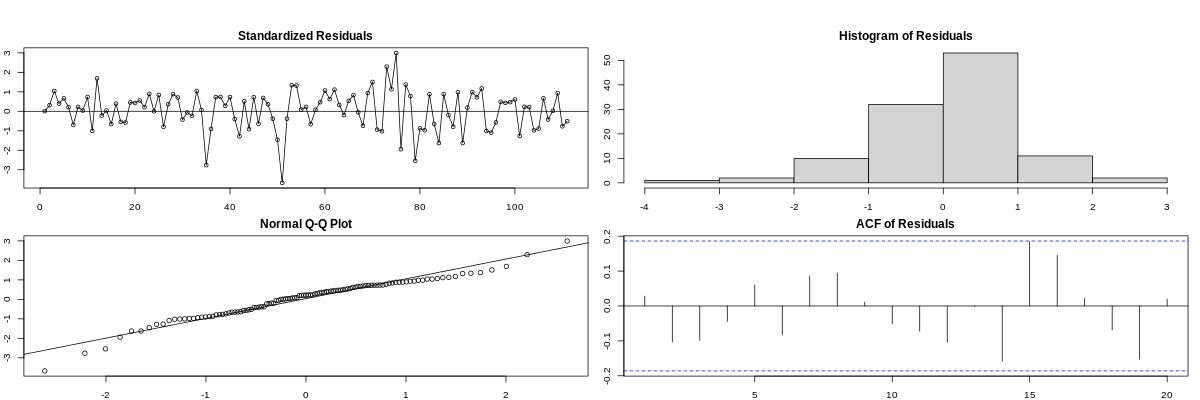

In [20]:
%%R -w 1200 -h 400
#arima(1, 1, 0)
diag_arima(fit1)


--- Ljung-Box test ---

	Box-Ljung test

data:  res
X-squared = 5.0939, df = 10, p-value = 0.8848


--- Shapiro normality test ---

	Shapiro-Wilk normality test

data:  res
W = 0.96193, p-value = 0.002981


--- Runs test ---
$pvalue
[1] 0.902

$observed.runs
[1] 56

$expected.runs
[1] 54.87387

$n1
[1] 46

$n2
[1] 65

$k
[1] 0



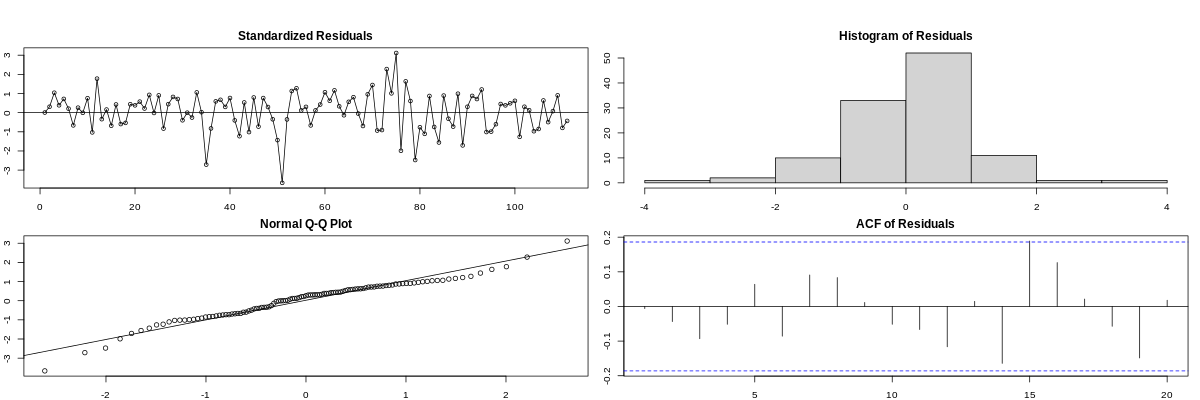

In [21]:
%%R -w 1200 -h 400
#arima(0, 1, 1)
diag_arima(fit2)


--- Ljung-Box test ---

	Box-Ljung test

data:  res
X-squared = 2.3325, df = 10, p-value = 0.9931


--- Shapiro normality test ---

	Shapiro-Wilk normality test

data:  res
W = 0.96777, p-value = 0.008694


--- Runs test ---
$pvalue
[1] 0.743

$observed.runs
[1] 52

$expected.runs
[1] 54.11712

$n1
[1] 44

$n2
[1] 67

$k
[1] 0



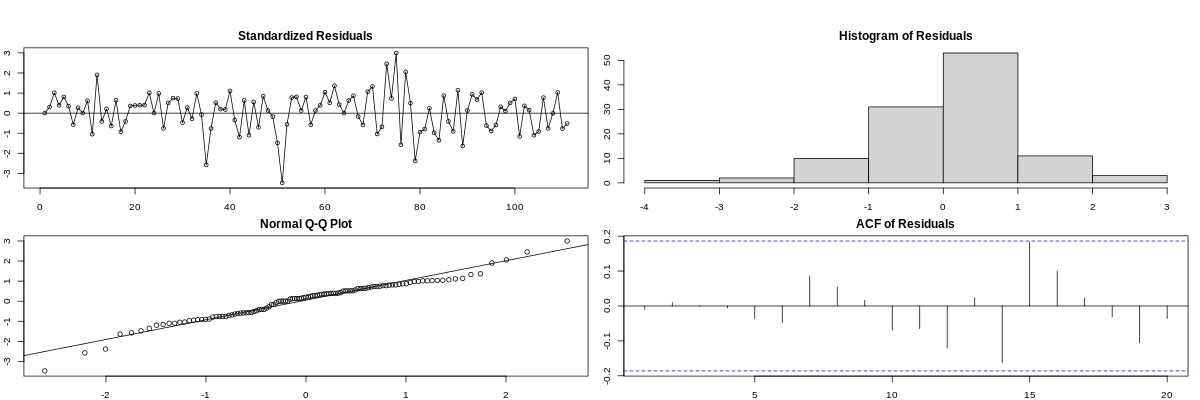

In [22]:
%%R -w 1200 -h 400
#arima(0, 1, 5)
diag_arima(fit3)


--- Ljung-Box test ---

	Box-Ljung test

data:  res
X-squared = 5.0367, df = 10, p-value = 0.8887


--- Shapiro normality test ---

	Shapiro-Wilk normality test

data:  res
W = 0.96189, p-value = 0.002959


--- Runs test ---
$pvalue
[1] 0.554

$observed.runs
[1] 58

$expected.runs
[1] 54.51351

$n1
[1] 45

$n2
[1] 66

$k
[1] 0



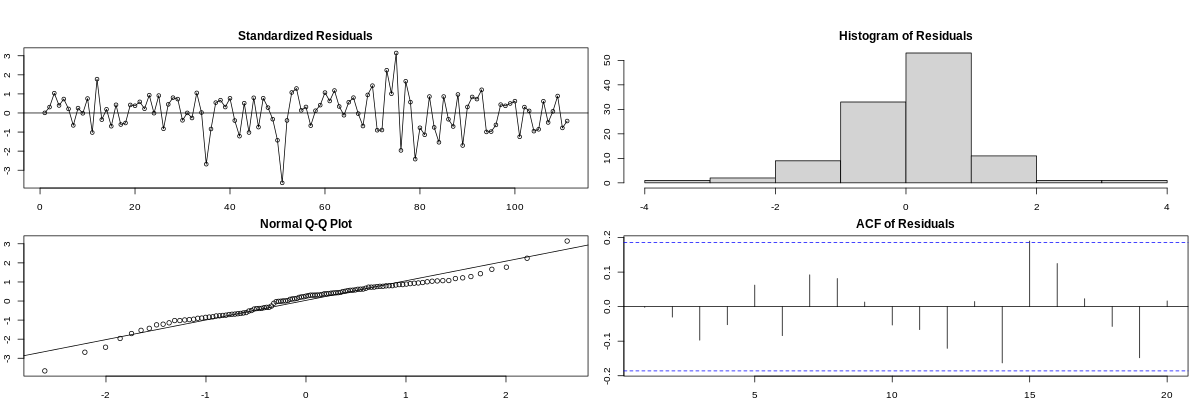

In [23]:
%%R -w 1200 -h 400
#arima(1, 1, 1)
diag_arima(fit4)

### Residual Diagnostics

Residual diagnostics were applied to all candidate models. The results are consistent across models:

- **Zero mean & constant variance:** The standardized residual plot fluctuates around zero with roughly constant variance throughout the sample period, with the exception of the two previously identified outliers (COVID-19 2020, Russia-Ukraine war 2022)
- **No autocorrelation:** The ACF of residuals shows no significant spikes, and the **Ljung-Box test** fails to reject the null hypothesis of white noise (p-value > 0.05), confirming that no autocorrelation structure remains in the residuals
- **Randomness:** The **Runs test** confirms that residuals are randomly distributed with no systematic pattern
- **Normality:** The histogram and QQ-plot suggest approximate normality, however the **Shapiro-Wilk test** rejects normality (p-value < 0.05). This is likely due to the test's **high sensitivity to extreme values** — the two shock-driven outliers are sufficient to cause rejection even when the bulk of residuals behave normally. This is a known limitation of Shapiro-Wilk in the presence of structural breaks.

All four models pass the diagnostic checks and can be considered **adequate**. Based on the model selection criteria established earlier, **$ARIMA(0,1,1)$ is confirmed as the final model**.

> **Note:** Due to the non-normality of residuals caused by extreme outliers, the **forecast confidence intervals should be interpreted with caution** as they rely on the normality assumption.

## Forecasting

In [24]:
%%R
final_fit <- Arima(y_train, order=c(0,1,1), method='ML')


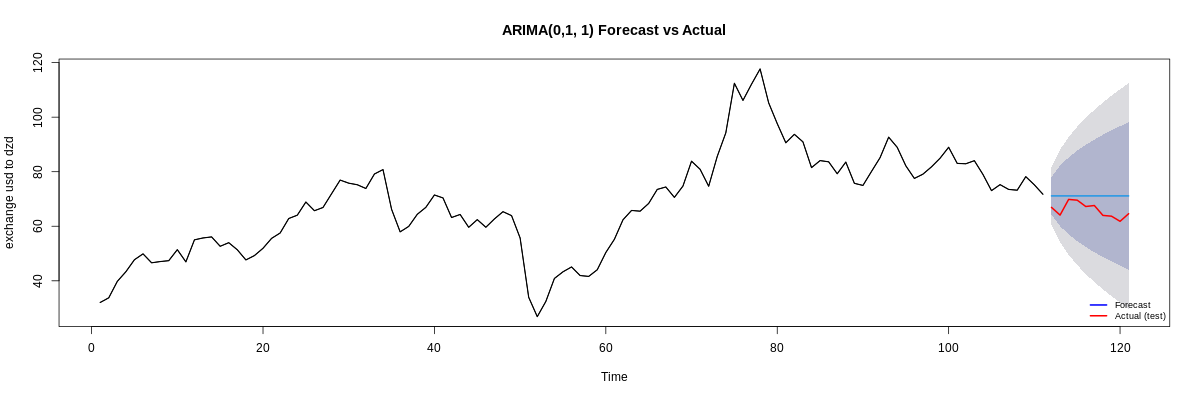

In [25]:
%%R -w 1200 -h 400
forecast_arima <- forecast(final_fit, h)
n_train <- length(x_train)
n_all   <- length(X)

plot(forecast_arima,
     xlim = c(1, n_all),
     ylim = range(c(y_train, y_test)),
     main = "ARIMA(0,1, 1) Forecast vs Actual",
     xlab = "Time", ylab = "Oil prices",
     flty = 1)                          # forecast line solid

# Full training series
lines(1:n_train, y_train, col = "black", lwd = 1.5)

# Actual test values
lines((n_train + 1):n_all, y_test, col = "red", lwd = 2)

# Compact legend — bottom right to avoid data
legend("bottomright",
       legend = c("Forecast", "Actual (test)"),
       col    = c( "blue",  "red"),
       lwd    = c(2, 2),
       bty    = "n",        # no box around legend
       cex    = 0.75)       # smaller font size


In [26]:
%%R
accuracy(forecast_arima, y_test)

                     ME     RMSE      MAE        MPE     MAPE     MASE
Training set  0.2784785 5.327150 4.180562  0.2958832 6.428264 0.969644
Test set     -5.1922223 5.784557 5.192222 -8.0356779 8.035678 1.204290
                     ACF1
Training set -0.006148298
Test set               NA


## Forecast Results & Interpretation

### Visual Inspection

The forecast (blue line) lies **above** the actual test values (red line) throughout the entire 10-month horizon, indicating that the model **systematically overestimates** oil prices. However, the actual values remain **within the 95% confidence interval**, which confirms that while the point forecast is biased upward, the model uncertainty is correctly captured.

The wide confidence intervals reflect the **high unpredictability of oil prices**, consistent with the residual non-normality observed in the diagnostic phase.

---
###  Accuracy Metrics

| Metric | Training | Test | Interpretation |
|--------|--------|------|----------------|
| **RMSE** | 5.33 | 5.79 | Slight increase on test — generalization is acceptable |
| **MAE** | 4.18 | 5.19 | Average prediction error ≈ 5.2 $/barrel |
| **MASE** | 0.97 | 1.20 | > 1 on test → worse than naïve (random walk) benchmark |

### Why is the Forecast Above Actual Values?

The upward bias is explained the **Structural break**, The model was trained on a period that includes the 2022 price peak. The subsequent decline is a regime change the model cannot anticipate.


### Conclusion

## Conclusion

This analysis applied the **Box-Jenkins ARIMA methodology** to model and forecast the monthly global price of Brent Crude Oil over the period 2016–2025.

### What Was Achieved
- The series was identified as **non-stationary and integrated of order 1 — I(1)**, requiring first-order differencing
- Through systematic model identification and comparison, **$ARIMA(0,1,1)$** was selected as the most appropriate model based on lowest BIC, parameter parsimony, and diagnostic adequacy
- All residual diagnostic checks (white noise, randomness, zero mean) were satisfied, confirming model adequacy
- The model produced a **10-month ahead forecast** with a MAPE of ~8%, capturing the general price level while actual values remained within the 95% confidence interval

### Limitations
- **Non-normality of residuals:** Driven by extreme shocks (COVID-19, Russia-Ukraine war), which causes the confidence intervals to be unreliable
- **Structural breaks:** The model is trained on a period including the 2022 price peak and cannot adapt to the subsequent declining regime, leading to systematic overestimation in the test period
- **MASE > 1:** On this specific test window, the model underperforms a naïve random walk, highlighting the difficulty of forecasting commodity prices during trend reversals
- **ARIMA assumes linearity** and cannot capture volatility clustering or asymmetric responses to shocks

### Possible Improvements
- **GARCH / EGARCH model:** To explicitly model the volatility of oil price changes, which is particularly relevant around shock periods
- **Rolling window forecast:** Instead of a fixed training set, refit the model at each step to adapt to structural changes
- **Intervention / transfer function models:** Formally incorporate external shocks (COVID, geopolitical events) as dummy regressors to improve in-sample fit and residual normality
- **Regime-switching models (Markov Switching ARIMA):** To capture the distinct behavioral regimes (stable growth, crash, recovery, decline) observed in the data